# Bridge Fatigue: Classical Monte Carlo vs Quantum Amplitude Estimation

This notebook frames bridge fatigue as an expectation-estimation problem.

The stochastic input is a random scenario

$X = (S, n, C, m, F_y, \ldots)$

where the components describe stress amplitude, cycle count, S-N curve parameters, material strength, and related traffic/material uncertainty. A fatigue model maps that scenario to a target value

$Y = D(X)$.

Classical Monte Carlo estimates the expectation by sampling many scenarios and averaging

$E[D(X)] \approx \frac{1}{M}\sum_{j=1}^{M}D(X_j)$.

The QAE formulation estimates the same expectation by encoding the stochastic input distribution into a quantum state, encoding the target damage value into an ancilla amplitude, and estimating that amplitude.

The notebook uses a small bucketed oracle so it can run on a simulator and on IBM hardware. This is a deliberate educational approximation: it demonstrates the QAE structure without implementing a full reversible arithmetic fatigue model.


## Runtime Configuration

This notebook can be shared without a `.env` file. Non-secret IBM Runtime settings are defined below. The IBM Quantum token is intentionally not stored in the notebook; the code prompts for it at runtime if it is not already available in the environment.

Do not paste a real IBM Quantum token into a saved notebook. If a token has already been shared or committed, revoke/rotate it in IBM Quantum before continuing.


In [95]:
import os
from getpass import getpass

# IBM Runtime target configuration.
os.environ.setdefault("IBM_QUANTUM_CHANNEL", "ibm_quantum_platform")
os.environ.setdefault("IBM_QUANTUM_BACKEND", "ibm_kingston")

# Optional. Uncomment if your IBM Quantum access requires an instance.
# os.environ.setdefault("IBM_QUANTUM_INSTANCE", "hub/group/project")

# Optional. Use this instead of token/channel if you saved a local Runtime account.
# os.environ.setdefault("IBM_QUANTUM_ACCOUNT", "default")

# Real hardware runs are opt-in.
os.environ.setdefault("RUN_KINGSTON_HARDWARE", "true")
os.environ.setdefault("RUN_KINGSTON_QAE", "true")
os.environ.setdefault("KINGSTON_SUBMIT_CONFIRM", "submit-real-ibm-job")
os.environ.setdefault("KINGSTON_INPUT_QUBITS", "4")
os.environ.setdefault("KINGSTON_QAE_INPUT_QUBITS", "4")
os.environ.setdefault("KINGSTON_SHOTS", "4096")

# Separate controls for the simplified polynomial-oracle hardware demo.
os.environ.setdefault("RUN_KINGSTON_SIMPLE_HARDWARE", "false")
os.environ.setdefault("RUN_KINGSTON_SIMPLE_QAE", "false")
os.environ.setdefault("KINGSTON_SIMPLE_INPUT_QUBITS", "4")

# Keep the token out of the notebook file. Paste it only into the hidden prompt.
if not os.getenv("IBM_QUANTUM_ACCOUNT"):
    token = os.getenv("IBM_QUANTUM_TOKEN")
    if not token or token == "replace-with-your-token":
        token = getpass("IBM Quantum token (input hidden, not saved in notebook): ").strip()
        if token:
            os.environ["IBM_QUANTUM_TOKEN"] = token


In [96]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation

RNG_SEED = 123
rng = np.random.default_rng(RNG_SEED)

data_file = "Bridge_Fatigue_MonteCarlo_InputData.csv"
candidate_paths = [Path(data_file), Path("fatigue_assessment") / data_file]
input_path = next((path for path in candidate_paths if path.exists()), None)
if input_path is None:
    raise FileNotFoundError(f"Could not find {data_file}. Run from the repo root or fatigue_assessment folder.")

df = pd.read_csv(input_path)
df.head()


,Sample_ID,Truck_Mass_t,Vehicles_Per_Day,Steel_Yield_Strength_MPa,Stress_Amplitude_MPa,SN_Coefficient_C,SN_Exponent_m,Cycles_Per_Day
0,1,38.14,4067,358.5,132.33,9.299950e+11,3.097,8134
1,2,25.20,4254,310.6,99.83,7.785530e+11,3.259,8508
2,3,28.20,4267,332.9,77.11,9.020680e+11,3.099,8534
3,4,30.45,4240,322.2,120.68,9.081030e+11,3.111,8480
4,5,23.27,4266,356.8,73.50,9.738750e+11,3.298,8532


## Original Fatigue Model

The underlying classical fatigue model is based on an S-N relation. For one scenario $X_i$, the estimated number of cycles to failure is

$N_i = C_i S_i^{-m_i}$

where $S_i$ is stress amplitude, and $C_i, m_i$ are S-N curve parameters. Miner's rule then gives daily damage

$D_i^{\text{Miner}} = \frac{n_i}{N_i} = \frac{n_i}{C_i S_i^{-m_i}}$

where $n_i$ is the number of cycles per day. If daily loading is stationary and damage accumulates linearly, a simple mean-damage lifetime proxy is

$T \approx \frac{1}{E[D_i^{\text{Miner}}]}$ days.

The original notebook divided this damage once more by yield strength:

$D_i = \frac{n_i}{C_i S_i^{-m_i} F_{y,i}}$.

That quantity is retained here as `daily_damage_score` so the experiment stays consistent with the original code. It should be described as a normalized fatigue damage score unless the extra $F_y$ factor is justified by the engineering model. For a strict Miner's-rule model, remove the division by $F_y$.

Important interpretation: `1 / mean(D)` is a deterministic proxy based on expected daily damage. It is not the same as estimating the full distribution of failure time, and it is not the same as $E[1/D]$.


In [97]:
def miner_damage_per_day(frame: pd.DataFrame) -> pd.Series:
    cycles = frame["Cycles_Per_Day"]
    c_coeff = frame["SN_Coefficient_C"]
    stress = frame["Stress_Amplitude_MPa"]
    exponent = frame["SN_Exponent_m"]
    return cycles / (c_coeff * stress ** (-exponent))


def daily_damage_score(frame: pd.DataFrame) -> pd.Series:
    return miner_damage_per_day(frame) / frame["Steel_Yield_Strength_MPa"]


df["daily_damage_score"] = daily_damage_score(df)
mc_mean = df["daily_damage_score"].mean()
mc_std = df["daily_damage_score"].std(ddof=1)
years_from_mean_damage = 1 / mc_mean / 365

summary = pd.DataFrame(
    {
        "quantity": ["MC mean daily damage score", "MC std daily damage score", "1 / mean damage, years"],
        "value": [mc_mean, mc_std, years_from_mean_damage],
    }
)
summary


,quantity,value
0,MC mean daily damage score,0.000036
1,MC std daily damage score,0.000051
2,"1 / mean damage, years",76.022494


## Classical Monte Carlo Baseline

The CSV is treated as a Monte Carlo sample of stochastic scenarios. Each row is one realization of the random input vector $X$. The classical estimator is the sample mean

$\hat{\mu}_M = \frac{1}{M}\sum_{j=1}^{M}D(X_j)$.

For independent samples, the standard error scales as

$\text{SE}(\hat{\mu}_M) = \frac{\sigma_D}{\sqrt{M}}$.

Therefore, to reduce absolute error to order $\epsilon$, classical MC needs

$M = O(1 / \epsilon^2)$

samples. The practical bottleneck is not only drawing samples, but evaluating a potentially expensive fatigue model for each sampled scenario. In this notebook the fatigue model is cheap because the data is already tabulated, but in a larger reliability workflow each $D(X_j)$ might require structural simulation, stress extraction, or load-history processing.


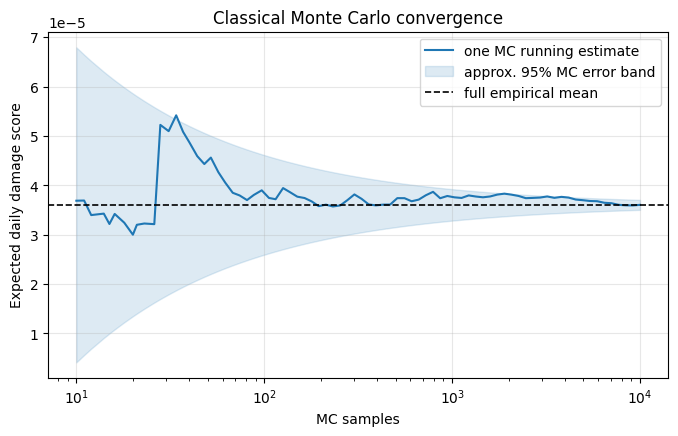

In [98]:
damage_values = df["daily_damage_score"].to_numpy()
order = rng.permutation(len(damage_values))
running_mean = np.cumsum(damage_values[order]) / np.arange(1, len(damage_values) + 1)

sample_sizes = np.unique(np.geomspace(10, len(damage_values), 80).astype(int))
mc_curve = running_mean[sample_sizes - 1]
standard_error = mc_std / np.sqrt(sample_sizes)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sample_sizes, mc_curve, label="one MC running estimate", color="tab:blue")
ax.fill_between(
    sample_sizes,
    mc_mean - 1.96 * standard_error,
    mc_mean + 1.96 * standard_error,
    color="tab:blue",
    alpha=0.15,
    label="approx. 95% MC error band",
)
ax.axhline(mc_mean, color="black", linestyle="--", linewidth=1.2, label="full empirical mean")
ax.set_xscale("log")
ax.set_xlabel("MC samples")
ax.set_ylabel("Expected daily damage score")
ax.set_title("Classical Monte Carlo convergence")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## QAE Encoding

The quantum experiment discretizes the stochastic input distribution into equal-probability buckets. Each basis state $|i\rangle$ represents one bucket of underlying input scenarios, not just an arbitrary output value. In this notebook the buckets are formed by stress-amplitude quantiles, and each bucket keeps the conditional distribution of the full input vector from the CSV.

For the implemented bucket model, the state preparation is

$A|0\rangle = \frac{1}{\sqrt{N}} \sum_{i=0}^{N-1} |i\rangle \left(\sqrt{1 - g_i}|0\rangle + \sqrt{g_i}|1\rangle\right)$

where

$g_i = \frac{E[D(X) \mid X \in \text{bucket } i]}{s}$

and $s$ is a scale factor chosen so that every $g_i \in [0, 1]$.

The probability of measuring the objective qubit in state $|1\rangle$ is

$a = P(1) = \frac{1}{N}\sum_i g_i = \frac{E[D(X)]}{s}$.

QAE estimates $a$, and the damage expectation is recovered as

$E[D(X)] = s a$.

Ideal version: instead of precomputing bucket conditional means, a full quantum fatigue oracle would encode the stochastic variables themselves and compute

$D(X) = \frac{n}{C S^{-m} F_y}$

reversibly with fixed-point quantum arithmetic. That would be the cleanest analogue of QAE option pricing, where the underlying random variable is prepared in superposition and the payoff is computed inside the circuit. The bucket oracle used here is a smaller, runnable approximation of that ideal construction.


In [99]:
def make_equal_probability_buckets(frame: pd.DataFrame, input_qubits: int) -> pd.DataFrame:
    n_buckets = 2**input_qubits
    ordered = frame.sort_values("Stress_Amplitude_MPa").reset_index(drop=True).copy()
    bucket_size = len(ordered) // n_buckets
    usable_rows = bucket_size * n_buckets
    ordered = ordered.iloc[:usable_rows].copy()
    ordered["bucket"] = np.repeat(np.arange(n_buckets), bucket_size)

    bucket_summary = (
        ordered.groupby("bucket", observed=True)
        .agg(
            probability=("daily_damage_score", lambda s: len(s) / usable_rows),
            stress_mean=("Stress_Amplitude_MPa", "mean"),
            cycles_mean=("Cycles_Per_Day", "mean"),
            c_mean=("SN_Coefficient_C", "mean"),
            m_mean=("SN_Exponent_m", "mean"),
            yield_mean=("Steel_Yield_Strength_MPa", "mean"),
            damage_mean=("daily_damage_score", "mean"),
        )
        .reset_index()
    )
    return bucket_summary


buckets_8 = make_equal_probability_buckets(df, input_qubits=3)
buckets_8


,bucket,probability,stress_mean,cycles_mean,c_mean,m_mean,yield_mean,damage_mean
0,0,0.125,70.807400,8397.6176,1.003297e+12,2.993626,356.15168,0.000012
1,1,0.125,81.011824,8400.3744,9.943658e+11,3.000208,353.41152,0.000019
2,2,0.125,86.809296,8398.2352,1.002920e+12,2.991080,355.20088,0.000023
3,3,0.125,92.151120,8398.6688,9.927471e+11,3.003757,356.07376,0.000029
4,4,0.125,97.664864,8403.4656,1.006568e+12,3.006374,354.30632,0.000035
5,5,0.125,103.673736,8403.1376,9.967952e+11,2.996062,356.41904,0.000041
6,6,0.125,111.543952,8395.9168,1.001273e+12,2.999307,354.42024,0.000050
7,7,0.125,127.269560,8396.1424,1.001426e+12,2.999835,355.68088,0.000078


In [100]:
def build_qae_problem(bucket_damage: np.ndarray) -> tuple[EstimationProblem, float, QuantumCircuit]:
    n_buckets = len(bucket_damage)
    input_qubits = int(np.log2(n_buckets))
    if 2**input_qubits != n_buckets:
        raise ValueError("The number of buckets must be a power of two.")

    scale = float(bucket_damage.max() * 1.05)
    normalized_damage = bucket_damage / scale
    if np.any(normalized_damage < 0) or np.any(normalized_damage > 1):
        raise ValueError("Normalized damage must be in [0, 1] for amplitude encoding.")

    objective_qubit = input_qubits
    qc = QuantumCircuit(input_qubits + 1)

    for qubit in range(input_qubits):
        qc.h(qubit)

    for index, damage in enumerate(normalized_damage):
        theta = 2 * np.arcsin(np.sqrt(float(damage)))
        bit_string = format(index, f"0{input_qubits}b")

        for qubit, bit in enumerate(bit_string):
            if bit == "0":
                qc.x(qubit)

        qc.mcry(theta, list(range(input_qubits)), objective_qubit)

        for qubit, bit in enumerate(bit_string):
            if bit == "0":
                qc.x(qubit)

    problem = EstimationProblem(state_preparation=qc.copy(name="A"), objective_qubits=[objective_qubit])
    return problem, scale, qc


def run_qae_for_buckets(bucket_summary: pd.DataFrame, epsilon_target: float = 0.005) -> dict:
    bucket_damage = bucket_summary["damage_mean"].to_numpy()
    problem, scale, circuit = build_qae_problem(bucket_damage)

    iae = IterativeAmplitudeEstimation(
        epsilon_target=epsilon_target,
        alpha=0.05,
        sampler=StatevectorSampler(default_shots=4096, seed=RNG_SEED),
    )
    result = iae.estimate(problem)

    qae_mean = result.estimation * scale
    exact_bucket_mean = float(bucket_damage.mean())
    return {
        "input_qubits": int(np.log2(len(bucket_damage))),
        "buckets": len(bucket_damage),
        "exact_bucket_mean": exact_bucket_mean,
        "qae_mean": qae_mean,
        "qae_abs_error_vs_bucket": abs(qae_mean - exact_bucket_mean),
        "qae_rel_error_vs_mc": (qae_mean / mc_mean) - 1,
        "amplitude_scale": scale,
        "circuit_depth": circuit.depth(),
    }


qae_results = pd.DataFrame(
    run_qae_for_buckets(make_equal_probability_buckets(df, input_qubits=n), epsilon_target=0.005)
    for n in [2, 3, 4]
)
qae_results


,input_qubits,buckets,exact_bucket_mean,qae_mean,qae_abs_error_vs_bucket,qae_rel_error_vs_mc,amplitude_scale,circuit_depth
0,2,4,0.000036,0.000036,1.727729e-08,0.000479,0.000067,18
1,3,8,0.000036,0.000036,2.156045e-08,0.000598,0.000082,106
2,4,16,0.000036,0.000036,2.846171e-08,0.000790,0.000097,705


## QAE Circuit Construction From Scratch

This section follows the naming convention used in the Qiskit Finance amplitude-estimation tutorial: `A` is the state-preparation operator, `Q` is the Grover/amplification operator, and `objective_qubits` identify the good state $|\Psi_1\rangle$.

The construction is split into explicit pieces:

- `P_X`: prepares the bucketized stochastic input distribution.
- `D_oracle`: loads the target damage value into the objective-qubit amplitude.
- `A = D_oracle P_X`: prepares the full amplitude-estimation state.
- `Q`: repeatedly amplifies the good-state amplitude.

The goal is educational rather than hardware-scale. We use 4 buckets, i.e. 2 input qubits plus 1 objective qubit, so that the circuits and amplitude-estimation bins are easy to inspect.

Reference naming pattern: Qiskit Finance, "Quantum Amplitude Estimation", https://qiskit-community.github.io/qiskit-finance/tutorials/00_amplitude_estimation.html


In [101]:
from qiskit_algorithms import AmplitudeEstimation

scratch_input_qubits = 2
scratch_buckets = make_equal_probability_buckets(df, input_qubits=scratch_input_qubits)
scratch_bucket_damage = scratch_buckets["damage_mean"].to_numpy()

scratch_scale = float(scratch_bucket_damage.max() * 1.05)
scratch_normalized_damage = scratch_bucket_damage / scratch_scale
objective_qubit = scratch_input_qubits
objective_qubits = [objective_qubit]
num_scratch_qubits = scratch_input_qubits + 1

# P_X prepares the bucketized stochastic input distribution.
P_X = QuantumCircuit(num_scratch_qubits, name="P_X")
for qubit in range(scratch_input_qubits):
    P_X.h(qubit)

# D_oracle encodes the target damage value into the objective-qubit amplitude.
D_oracle = QuantumCircuit(num_scratch_qubits, name="D_oracle")
for index, damage in enumerate(scratch_normalized_damage):
    theta = 2 * np.arcsin(np.sqrt(float(damage)))
    bit_string = format(index, f"0{scratch_input_qubits}b")

    for qubit, bit in enumerate(bit_string):
        if bit == "0":
            D_oracle.x(qubit)

    D_oracle.mcry(theta, list(range(scratch_input_qubits)), objective_qubit)

    for qubit, bit in enumerate(bit_string):
        if bit == "0":
            D_oracle.x(qubit)

# A is the state-preparation operator used by amplitude estimation.
A = QuantumCircuit(num_scratch_qubits, name="A")
A.compose(P_X, inplace=True)
A.compose(D_oracle, inplace=True)

base_problem = EstimationProblem(state_preparation=A, objective_qubits=objective_qubits)

# Q is the Grover operator used to amplify the objective-qubit amplitude.
Q = base_problem.grover_operator
Q.name = "Q"

# Rebuild the EstimationProblem explicitly, matching the tutorial's naming.
problem_from_scratch = EstimationProblem(
    state_preparation=A,  # A operator
    grover_operator=Q,  # Q operator
    objective_qubits=objective_qubits,  # good state is objective qubit measured as |1>
)

a_exact = float(scratch_bucket_damage.mean() / scratch_scale)
d_exact = float(scratch_bucket_damage.mean())

pd.DataFrame(
    {
        "object": ["P_X", "D_oracle", "A", "Q", "objective_qubits", "a = E[D]/scale", "E[D] bucket exact", "E[D] MC empirical"],
        "value": [
            f"prepare {2**scratch_input_qubits} equal-probability input buckets",
            f"controlled rotations, depth {D_oracle.depth()}",
            f"{A.num_qubits} qubits, depth {A.depth()}",
            f"{Q.num_qubits} qubits, depth {Q.depth()}",
            str(objective_qubits),
            a_exact,
            d_exact,
            mc_mean,
        ],
    }
)


,object,value
0,P_X,prepare 4 equal-probability input buckets
1,D_oracle,"controlled rotations, depth 17"
2,A,"3 qubits, depth 18"
3,Q,"3 qubits, depth 1"
4,objective_qubits,[2]
5,a = E[D]/scale,0.535596
6,E[D] bucket exact,0.000036
7,E[D] MC empirical,0.000036


### Defining the Reflections

The amplitude-amplification operator can be written as

$Q = A S_0 A^\dagger S_{\Psi_1}$.

Here:

- $S_{\Psi_1}$ flips the phase of states where the objective qubit is $|1\rangle$.
- $S_0$ flips the phase of the all-zero state.
- Applying powers $Q^k A|0\rangle$ rotates probability mass between the bad and good subspaces.

In this simplified bucket model, $S_{\Psi_1}$ is just a phase flip on the objective qubit. The code below constructs these pieces explicitly for inspection. The `EstimationProblem` version of `Q` is the operator used by the algorithms.


In [102]:
num_scratch_qubits = A.num_qubits

S_psi1 = QuantumCircuit(num_scratch_qubits, name="S_Psi1")
S_psi1.z(objective_qubit)

S_0 = QuantumCircuit(num_scratch_qubits, name="S_0")
S_0.x(range(num_scratch_qubits))
S_0.h(num_scratch_qubits - 1)
S_0.mcx(list(range(num_scratch_qubits - 1)), num_scratch_qubits - 1)
S_0.h(num_scratch_qubits - 1)
S_0.x(range(num_scratch_qubits))

Q_from_scratch = QuantumCircuit(num_scratch_qubits, name="Q_from_scratch")
Q_from_scratch.compose(S_psi1, inplace=True)
Q_from_scratch.compose(A.inverse(), inplace=True)
Q_from_scratch.compose(S_0, inplace=True)
Q_from_scratch.compose(A, inplace=True)

pd.DataFrame(
    {
        "operator": ["S_Psi1", "S_0", "Q_from_scratch", "Q from EstimationProblem"],
        "meaning": [
            "phase flip for objective qubit = 1",
            "reflection about all-zero state",
            "manual composition A S0 A† S_Psi1",
            "Qiskit-generated Grover operator used below",
        ],
        "qubits": [S_psi1.num_qubits, S_0.num_qubits, Q_from_scratch.num_qubits, Q.num_qubits],
        "depth": [S_psi1.depth(), S_0.depth(), Q_from_scratch.depth(), Q.depth()],
    }
)


,operator,meaning,qubits,depth
0,S_Psi1,phase flip for objective qubit = 1,3,1
1,S_0,reflection about all-zero state,3,5
2,Q_from_scratch,manual composition A S0 A† S_Psi1,3,40
3,Q from EstimationProblem,Qiskit-generated Grover operator used below,3,1


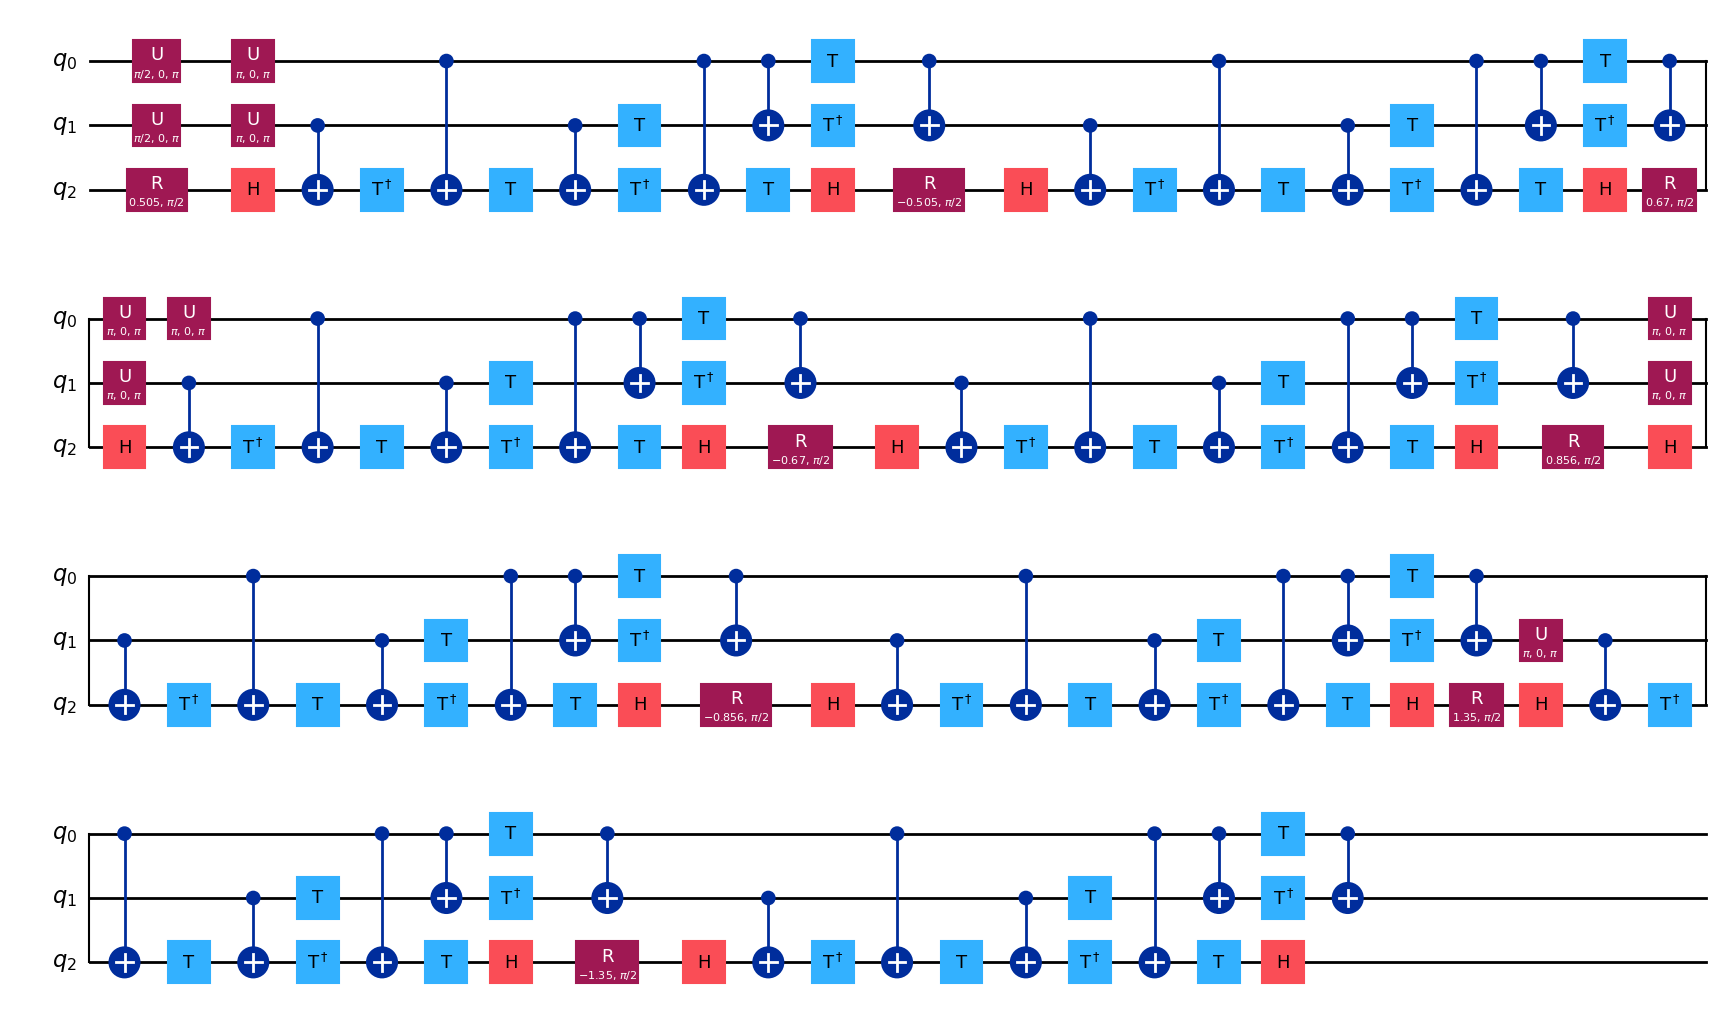

In [103]:
A.decompose(reps=1).draw("mpl")


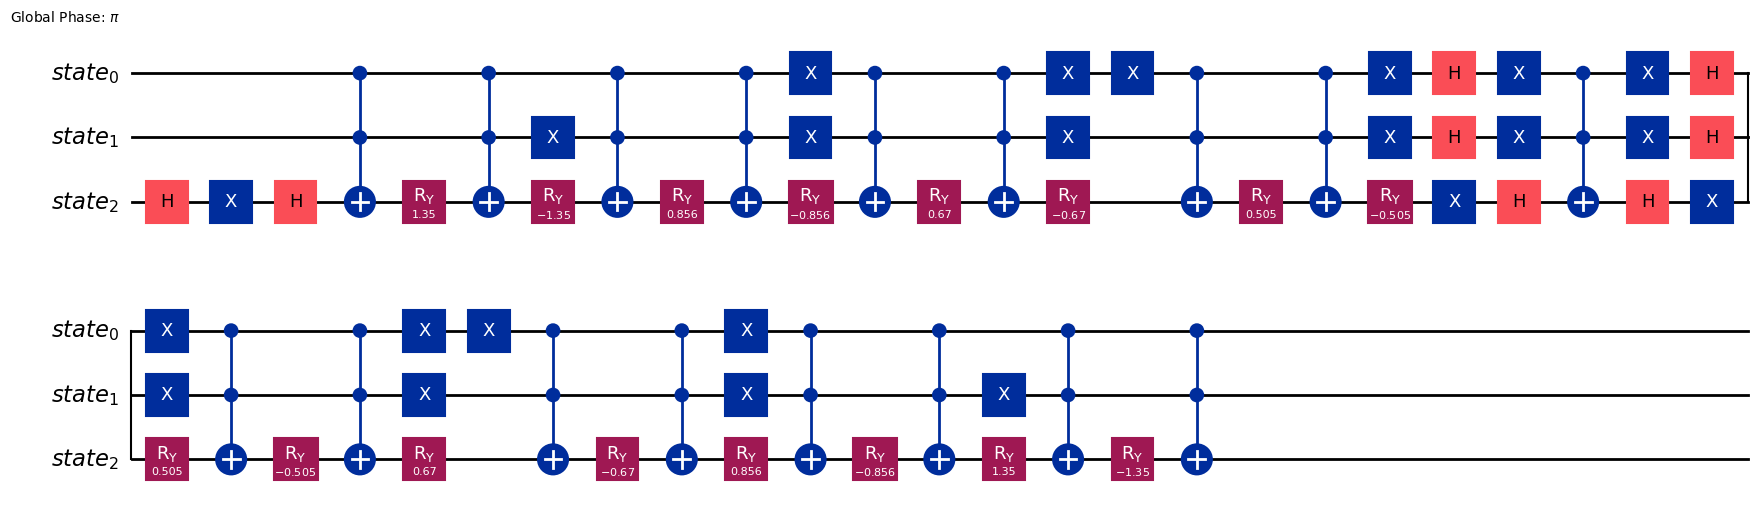

In [104]:
Q.decompose(reps=1).draw("mpl")


### Repeating the Grover Operator

If $a = \sin^2(\theta_a)$, then after applying $Q^k A$ the good-state probability becomes approximately

$\sin^2((2k + 1)\theta_a)$.

The table below samples circuits with several Grover powers. These probabilities are not expected to converge monotonically; they oscillate. QAE uses this oscillation to infer the original amplitude $a$ more efficiently than plain sampling.


In [105]:
def objective_probability_from_sampler(circuit: QuantumCircuit, shots: int = 4096) -> tuple[dict, float]:
    sampler = StatevectorSampler(default_shots=shots, seed=RNG_SEED)
    ret = sampler.run([(circuit,)], shots=shots).result()[0]
    register = getattr(ret.data, next(iter(ret.data.keys())))
    counts = register.get_counts()
    one_counts = sum(
        count for bitstring, count in counts.items()
        if bitstring.replace(" ", "")[-1] == "1"
    )
    return counts, one_counts / shots


iae_for_circuits = IterativeAmplitudeEstimation(
    epsilon_target=0.005,
    alpha=0.05,
    sampler=StatevectorSampler(default_shots=4096, seed=RNG_SEED),
)

power_rows = []
for k in [0, 1, 2, 4]:
    amplified_circuit = iae_for_circuits.construct_circuit(problem_from_scratch, k=k, measurement=True)
    counts, p_objective_1 = objective_probability_from_sampler(amplified_circuit, shots=4096)
    power_rows.append(
        {
            "Grover power k": k,
            "circuit": "A" if k == 0 else f"Q^{k} A",
            "depth": amplified_circuit.depth(),
            "P(objective=1) sampled": p_objective_1,
            "counts": counts,
        }
    )

pd.DataFrame(power_rows)


,Grover power k,circuit,depth,P(objective=1) sampled,counts
0,0,A,19,0.531738,"{'1': 2178, '0': 1918}"
1,1,Q^1 A,20,0.381104,"{'1': 1561, '0': 2535}"
2,2,Q^2 A,21,0.676270,"{'1': 2770, '0': 1326}"
3,4,Q^4 A,23,0.801025,"{'1': 3281, '0': 815}"


### Canonical AE Bins

Canonical amplitude estimation estimates $a$ on a discrete grid set by `num_eval_qubits`. This is why the tutorial plots estimated values as bins. The red line marks the exact bucket amplitude $a = E[D]/s$.

The maximum-likelihood value can be much better than the raw highest-probability grid point, but the grid picture is useful for understanding why finite evaluation qubits produce discretization error.


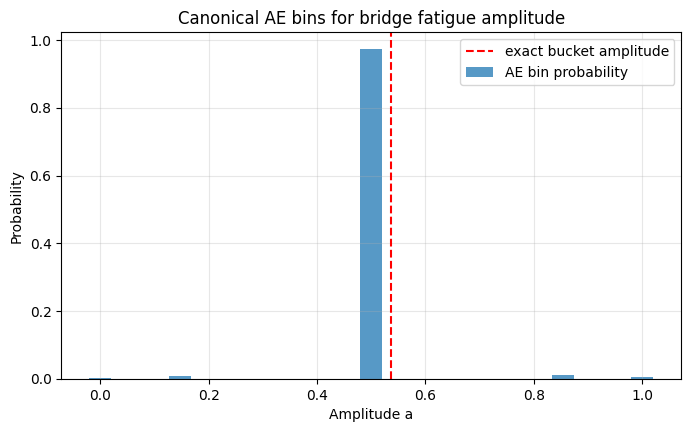

,quantity,value
0,raw AE grid estimate,0.500000
1,AE MLE,0.536016
2,exact bucket amplitude,0.535596
3,raw AE damage,0.000034
4,MLE damage,0.000036
5,exact bucket damage,0.000036


In [106]:
ae = AmplitudeEstimation(
    num_eval_qubits=3,
    sampler=StatevectorSampler(default_shots=4096, seed=RNG_SEED),
)
ae_result = ae.estimate(problem_from_scratch)

ae_bins = pd.DataFrame(
    {
        "amplitude_bin": list(ae_result.samples.keys()),
        "probability": list(ae_result.samples.values()),
    }
).sort_values("amplitude_bin")
ae_bins["damage_bin"] = ae_bins["amplitude_bin"] * scratch_scale

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ae_bins["amplitude_bin"], ae_bins["probability"], width=0.04, alpha=0.75, label="AE bin probability")
ax.axvline(a_exact, color="red", linestyle="--", linewidth=1.5, label="exact bucket amplitude")
ax.set_xlabel("Amplitude a")
ax.set_ylabel("Probability")
ax.set_title("Canonical AE bins for bridge fatigue amplitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

pd.DataFrame(
    {
        "quantity": ["raw AE grid estimate", "AE MLE", "exact bucket amplitude", "raw AE damage", "MLE damage", "exact bucket damage"],
        "value": [
            ae_result.estimation,
            ae_result.mle,
            a_exact,
            ae_result.estimation * scratch_scale,
            ae_result.mle * scratch_scale,
            d_exact,
        ],
    }
)


### Iterative AE Interval Convergence

Iterative Amplitude Estimation avoids the large phase-estimation circuit. Instead, it adaptively chooses Grover powers and narrows a confidence interval for the amplitude.

The plot below shows the interval for $a$ after each IAE step. Multiplying the interval endpoints by `scratch_scale` gives the corresponding interval for expected damage.


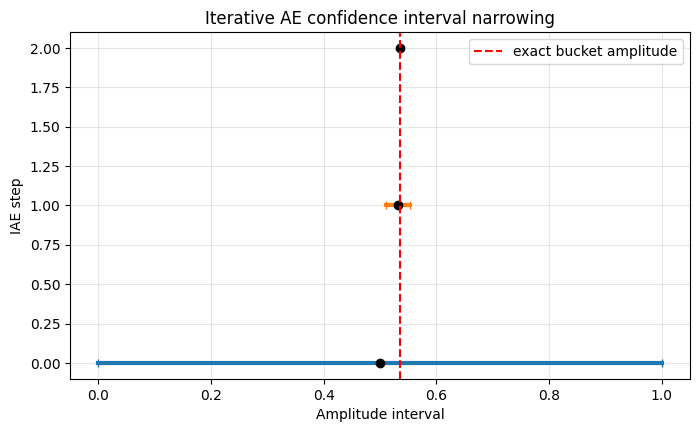

,step,Grover power k,theta_low,theta_high,a_low,a_high,a_mid,damage_low,damage_high,damage_mid
0,0,0,0.000000,0.250000,0.000000,1.000000,0.500000,0.000000,0.000067,0.000034
1,1,0,0.126634,0.133471,0.510267,0.553127,0.531697,0.000034,0.000037,0.000036
2,2,6,0.130447,0.130975,0.534199,0.537507,0.535853,0.000036,0.000036,0.000036


In [107]:
iae_step = IterativeAmplitudeEstimation(
    epsilon_target=0.005,
    alpha=0.05,
    sampler=StatevectorSampler(default_shots=4096, seed=RNG_SEED),
)
iae_step_result = iae_step.estimate(problem_from_scratch)

iae_steps = pd.DataFrame(
    {
        "step": range(len(iae_step_result.estimate_intervals)),
        "Grover power k": iae_step_result.powers,
        "theta_low": [interval[0] for interval in iae_step_result.theta_intervals],
        "theta_high": [interval[1] for interval in iae_step_result.theta_intervals],
        "a_low": [interval[0] for interval in iae_step_result.estimate_intervals],
        "a_high": [interval[1] for interval in iae_step_result.estimate_intervals],
    }
)
iae_steps["a_mid"] = (iae_steps["a_low"] + iae_steps["a_high"]) / 2
iae_steps["damage_low"] = iae_steps["a_low"] * scratch_scale
iae_steps["damage_high"] = iae_steps["a_high"] * scratch_scale
iae_steps["damage_mid"] = iae_steps["a_mid"] * scratch_scale

fig, ax = plt.subplots(figsize=(8, 4.5))
for _, row in iae_steps.iterrows():
    ax.plot([row["a_low"], row["a_high"]], [row["step"], row["step"]], marker="|", linewidth=3)
    ax.plot(row["a_mid"], row["step"], marker="o", color="black")
ax.axvline(a_exact, color="red", linestyle="--", linewidth=1.5, label="exact bucket amplitude")
ax.set_xlabel("Amplitude interval")
ax.set_ylabel("IAE step")
ax.set_title("Iterative AE confidence interval narrowing")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

iae_steps


## Output Sanity Check

The local simulator results are internally consistent. The exact bucket means are equal to the empirical MC mean because the buckets partition the same dataset into equal-probability groups. The QAE estimates are close to that bucket mean, which confirms that the amplitude encoding is estimating the intended expectation.

The circuit depth grows quickly: the saved logical depth is 18 for 4 buckets, 106 for 8 buckets, and 705 for 16 buckets. This is the main practical warning. The mathematical QAE formulation is valid, but the current lookup-style oracle becomes deep as bucket count grows.


## Validation

There are three consistency checks:

1. The classical running mean should settle near the full empirical MC mean.
2. The exact bucket mean should remain close to the full empirical MC mean.
3. The simulator QAE estimate should match the exact bucket mean within the requested QAE tolerance and shot noise.

The saved simulator outputs satisfy these checks. The full empirical MC mean is about $3.60 \times 10^{-5}$, and the simulator QAE estimates for 4, 8, and 16 buckets are within roughly $10^{-3}$ relative error of that value.

The bucket means increase with stress-amplitude bucket, which is physically sensible because higher stress amplitudes produce larger fatigue damage through the S-N power law.


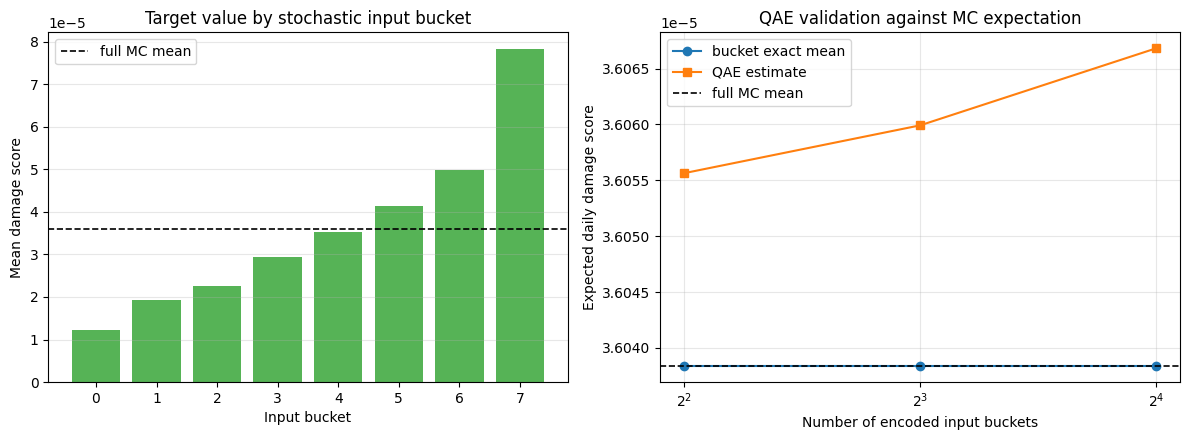

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(buckets_8["bucket"], buckets_8["damage_mean"], color="tab:green", alpha=0.8)
axes[0].axhline(mc_mean, color="black", linestyle="--", linewidth=1.2, label="full MC mean")
axes[0].set_xlabel("Input bucket")
axes[0].set_ylabel("Mean damage score")
axes[0].set_title("Target value by stochastic input bucket")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].plot(qae_results["buckets"], qae_results["exact_bucket_mean"], marker="o", label="bucket exact mean")
axes[1].plot(qae_results["buckets"], qae_results["qae_mean"], marker="s", label="QAE estimate")
axes[1].axhline(mc_mean, color="black", linestyle="--", linewidth=1.2, label="full MC mean")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Number of encoded input buckets")
axes[1].set_ylabel("Expected daily damage score")
axes[1].set_title("QAE validation against MC expectation")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Complexity Interpretation

This is a quantum-alternative formulation of the expectation-estimation stage:

- Classical MC samples scenarios $X_j$, computes $D(X_j)$, and averages.
- QAE prepares a distribution over scenarios or scenario buckets, encodes $D(X)$ into an amplitude, and estimates that amplitude.

In the ideal oracle model, classical MC requires

$O(1 / \epsilon^2)$

model evaluations to reach additive error $\epsilon$, while QAE requires

$O(1 / \epsilon)$

oracle calls. This is the same quadratic reduction that motivates QAE for option pricing.

The reduction is not automatic in wall-clock time. It applies to the number of calls to a well-defined quantum oracle. A practical advantage requires efficient state preparation and an efficient reversible implementation of the fatigue model. If the algorithm only loads a large classical lookup table, or if the fatigue oracle becomes too deep, the theoretical reduction can disappear.

For this notebook, the correct claim is therefore limited but meaningful: the notebook demonstrates how bridge fatigue can be cast into the same amplitude-estimation structure used in financial expectation estimation, while making the state-preparation and oracle-depth bottlenecks explicit.


## IBM Kingston Hardware Setup

The cells below connect the conceptual QAE experiment to IBM Quantum hardware. Credentials are loaded from `.env`; keep that file local and do not commit it.

`ibm_kingston` is configured as a 156-qubit target backend. The notebook adapts the logical circuit to the backend capacity, but it does not try to use all 156 qubits. With this bucket-lookup oracle, increasing input qubits increases bucket count as $2^n$, and therefore increases the number of controlled rotations exponentially.

For the default hardware configuration, `KINGSTON_INPUT_QUBITS=4` means 16 encoded buckets and 5 logical qubits including the objective qubit. The saved transpiled depth is much larger than the logical depth, which is expected on real hardware because multi-controlled rotations must be decomposed into native gates and routed through the device topology.

Submitting real IBM Quantum jobs requires two `.env` settings: set `RUN_KINGSTON_HARDWARE=true` or `RUN_KINGSTON_QAE=true`, and also set `KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job`. This second gate prevents accidental submissions when you run all notebook cells.


In [109]:
import os

from dotenv import load_dotenv
from qiskit import ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSamplerV2


def env_bool(name: str, default: bool = False) -> bool:
    value = os.getenv(name)
    if value is None:
        return default
    return value.strip().lower() in {"1", "true", "yes", "on"}


for env_path in [Path(".env"), Path("..") / ".env"]:
    if env_path.exists():
        load_dotenv(env_path, override=False)
        break

IBM_BACKEND_NAME = os.getenv("IBM_QUANTUM_BACKEND", "ibm_kingston")
IBM_CHANNEL = os.getenv("IBM_QUANTUM_CHANNEL", "ibm_quantum_platform")
IBM_INSTANCE = os.getenv("IBM_QUANTUM_INSTANCE") or None
IBM_ACCOUNT = os.getenv("IBM_QUANTUM_ACCOUNT") or None
IBM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN") or None
RUN_KINGSTON_HARDWARE = env_bool("RUN_KINGSTON_HARDWARE", default=False)
RUN_KINGSTON_QAE = env_bool("RUN_KINGSTON_QAE", default=False)
RUN_KINGSTON_SIMPLE_HARDWARE = env_bool("RUN_KINGSTON_SIMPLE_HARDWARE", default=False)
RUN_KINGSTON_SIMPLE_QAE = env_bool("RUN_KINGSTON_SIMPLE_QAE", default=False)
KINGSTON_SUBMIT_CONFIRM = os.getenv("KINGSTON_SUBMIT_CONFIRM", "")
KINGSTON_SUBMIT_CONFIRMED = KINGSTON_SUBMIT_CONFIRM == "submit-real-ibm-job"
KINGSTON_SHOTS = int(os.getenv("KINGSTON_SHOTS", "4096"))
EXPECTED_KINGSTON_QUBITS = 156


def build_runtime_service() -> QiskitRuntimeService:
    if IBM_ACCOUNT:
        return QiskitRuntimeService(name=IBM_ACCOUNT)
    if not IBM_TOKEN or IBM_TOKEN == "replace-with-your-token":
        raise RuntimeError("Set IBM_QUANTUM_TOKEN in .env, or set IBM_QUANTUM_ACCOUNT for a saved account.")

    kwargs = {"channel": IBM_CHANNEL, "token": IBM_TOKEN}
    if IBM_INSTANCE:
        kwargs["instance"] = IBM_INSTANCE
    return QiskitRuntimeService(**kwargs)


try:
    runtime_service = build_runtime_service()
    kingston_device = runtime_service.backend(IBM_BACKEND_NAME)
    kingston_qubits = int(kingston_device.num_qubits)
    print(f"Loaded backend {kingston_device.name} with {kingston_qubits} qubits.")
except Exception as exc:
    runtime_service = None
    kingston_device = None
    kingston_qubits = EXPECTED_KINGSTON_QUBITS
    print(f"IBM Runtime is not initialized yet: {exc}")
    print("Hardware cells will stay in dry-run mode until .env contains valid credentials.")

if kingston_qubits < EXPECTED_KINGSTON_QUBITS:
    print(f"Warning: expected at least {EXPECTED_KINGSTON_QUBITS} qubits, got {kingston_qubits}.")

if (RUN_KINGSTON_HARDWARE or RUN_KINGSTON_QAE or RUN_KINGSTON_SIMPLE_HARDWARE or RUN_KINGSTON_SIMPLE_QAE) and not KINGSTON_SUBMIT_CONFIRMED:
    print("Hardware submission flags are enabled, but submission is blocked.")
    print("Set KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job only when you intentionally want to submit jobs.")


qiskit_runtime_service._discover_account:WARNING:2026-05-07 10:02:16,634: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-07 10:02:22,178: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-07 10:02:22,178: Using instance: open-instance, plan: open


Loaded backend ibm_kingston with 156 qubits.


In [110]:
dataset_input_qubits = int(np.floor(np.log2(len(df))))
backend_input_qubits = max(1, kingston_qubits - 1)
requested_input_qubits = int(os.getenv("KINGSTON_INPUT_QUBITS", "4"))
kingston_input_qubits = min(requested_input_qubits, dataset_input_qubits, backend_input_qubits)

capacity = pd.DataFrame(
    {
        "constraint": [
            "configured backend qubits",
            "max input qubits from backend",
            "max input qubits from CSV rows",
            "requested input qubits",
            "selected input qubits",
            "selected encoded buckets",
        ],
        "value": [
            kingston_qubits,
            backend_input_qubits,
            dataset_input_qubits,
            requested_input_qubits,
            kingston_input_qubits,
            2**kingston_input_qubits,
        ],
    }
)
capacity


,constraint,value
0,configured backend qubits,156
1,max input qubits from backend,155
2,max input qubits from CSV rows,13
3,requested input qubits,4
4,selected input qubits,4
5,selected encoded buckets,16


## Kingston Direct Amplitude-Sampling Experiment

This hardware experiment prepares the same amplitude-encoded target as the simulator QAE section, then measures only the objective qubit. The estimate is

$\hat{E}[D(X)] = s \cdot \hat{P}(\text{objective}=1)$.

This is not full QAE; it is a one-job hardware validation of the amplitude encoding. It checks whether the prepared objective-qubit probability is in the same range as the MC expectation.

The saved output estimates a hardware damage mean around $4.8 \times 10^{-5}$ versus the MC empirical mean around $3.6 \times 10^{-5}$. That is the same order of magnitude, but biased high. Given the saved transpiled depth above 2000 gates, this bias is plausible and should be interpreted as hardware noise/decomposition error, not as evidence that the fatigue expectation is truly larger.


In [111]:
def build_measured_amplitude_circuit(input_qubits: int) -> dict:
    bucket_summary = make_equal_probability_buckets(df, input_qubits=input_qubits)
    bucket_damage = bucket_summary["damage_mean"].to_numpy()
    _, scale, state_circuit = build_qae_problem(bucket_damage)

    objective_qubit = input_qubits
    measured_circuit = state_circuit.copy(name=f"bridge_damage_{2**input_qubits}_buckets")
    objective_register = ClassicalRegister(1, "objective")
    measured_circuit.add_register(objective_register)
    measured_circuit.measure(objective_qubit, objective_register[0])

    return {
        "bucket_summary": bucket_summary,
        "scale": scale,
        "state_circuit": state_circuit,
        "measured_circuit": measured_circuit,
        "exact_bucket_mean": float(bucket_damage.mean()),
    }


kingston_experiment = build_measured_amplitude_circuit(kingston_input_qubits)
kingston_measured_circuit = kingston_experiment["measured_circuit"]

if kingston_device is not None:
    kingston_pass_manager = generate_preset_pass_manager(
        backend=kingston_device,
        optimization_level=1,
        seed_transpiler=RNG_SEED,
    )
    kingston_isa_circuit = kingston_pass_manager.run(kingston_measured_circuit)
else:
    kingston_pass_manager = None
    kingston_isa_circuit = kingston_measured_circuit

pd.DataFrame(
    {
        "metric": [
            "logical qubits used",
            "backend qubits available",
            "encoded buckets",
            "exact bucket mean",
            "MC empirical mean",
            "circuit depth before transpilation",
            "circuit depth after transpilation/dry-run",
        ],
        "value": [
            kingston_measured_circuit.num_qubits,
            kingston_qubits,
            2**kingston_input_qubits,
            kingston_experiment["exact_bucket_mean"],
            mc_mean,
            kingston_measured_circuit.depth(),
            kingston_isa_circuit.depth(),
        ],
    }
)


,metric,value
0,logical qubits used,5.000000
1,backend qubits available,156.000000
2,encoded buckets,16.000000
3,exact bucket mean,0.000036
4,MC empirical mean,0.000036
5,circuit depth before transpilation,706.000000
6,circuit depth after transpilation/dry-run,2463.000000


In [112]:
if RUN_KINGSTON_HARDWARE and KINGSTON_SUBMIT_CONFIRMED:
    if kingston_device is None:
        raise RuntimeError("Set valid IBM Quantum credentials in .env before submitting to hardware.")

    kingston_sampler = RuntimeSamplerV2(
        mode=kingston_device,
        options={"default_shots": KINGSTON_SHOTS},
    )
    kingston_hardware_job = kingston_sampler.run([kingston_isa_circuit], shots=KINGSTON_SHOTS)
    print(f"Submitted {IBM_BACKEND_NAME} hardware job: {kingston_hardware_job.job_id()}")
elif RUN_KINGSTON_HARDWARE:
    kingston_hardware_job = None
    print("Submission blocked: set KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job to submit this real hardware job.")
else:
    kingston_hardware_job = None
    print("Dry run only. Set RUN_KINGSTON_HARDWARE=true and KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job to submit this circuit to ibm_kingston.")


Submitted ibm_kingston hardware job: d7u4e4fmrars73d6ghr0


In [113]:
def get_objective_counts(runtime_result) -> dict:
    pub_result = runtime_result[0]
    data = pub_result.data

    for register_name in ["objective", "c", "meas"]:
        register = getattr(data, register_name, None)
        if register is not None and hasattr(register, "get_counts"):
            return register.get_counts()

    for register_name in dir(data):
        if register_name.startswith("_"):
            continue
        register = getattr(data, register_name)
        if hasattr(register, "get_counts"):
            return register.get_counts()

    raise RuntimeError("Could not find a measured classical register in the runtime result.")


def damage_mean_from_objective_counts(counts: dict, scale: float) -> dict:
    shots = sum(counts.values())
    one_shots = sum(count for bitstring, count in counts.items() if bitstring.replace(" ", "")[-1] == "1")
    probability_one = one_shots / shots
    return {
        "shots": shots,
        "p_objective_1": probability_one,
        "hardware_damage_mean": probability_one * scale,
    }


if kingston_hardware_job is not None:
    kingston_runtime_result = kingston_hardware_job.result()
    kingston_counts = get_objective_counts(kingston_runtime_result)
    kingston_hardware_estimate = damage_mean_from_objective_counts(kingston_counts, kingston_experiment["scale"])
    display(pd.DataFrame([kingston_hardware_estimate]))
else:
    kingston_counts = None
    kingston_hardware_estimate = None
    print("No hardware result yet. Run the submission cell after enabling RUN_KINGSTON_HARDWARE.")


,shots,p_objective_1,hardware_damage_mean
0,4096,0.481445,0.000047


## Optional Full Iterative QAE on Kingston

This cell runs the actual iterative QAE algorithm with IBM Runtime Sampler. It may submit multiple circuits/jobs because IAE evaluates amplified circuits at several powers of the Grover operator. It requires both `RUN_KINGSTON_QAE=true` and `KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job`.

The saved hardware QAE estimate is also around $4.85 \times 10^{-5}$, above the MC value of $3.60 \times 10^{-5}$. Since the direct amplitude-sampling hardware result is biased in the same direction, the likely explanation is hardware noise in the amplitude-preparation/oracle circuit, amplified further by IAE. The simulator result remains the reference for whether the mathematical encoding is correct.

For a defensible report, separate the conclusions:

- Simulator QAE validates the encoding and matches the MC expectation.
- Kingston hardware demonstrates feasibility of submitting the small circuit, but the current depth/noise level limits quantitative accuracy.
- The ideal QAE speedup is an oracle-query statement, not a claim that this specific hardware run already outperforms MC.


In [114]:
qae_requested_input_qubits = int(os.getenv("KINGSTON_QAE_INPUT_QUBITS", "2"))
kingston_qae_input_qubits = min(qae_requested_input_qubits, dataset_input_qubits, backend_input_qubits)
kingston_qae_buckets = make_equal_probability_buckets(df, input_qubits=kingston_qae_input_qubits)
kingston_qae_problem, kingston_qae_scale, kingston_qae_circuit = build_qae_problem(
    kingston_qae_buckets["damage_mean"].to_numpy()
)

from qiskit.primitives.containers import SamplerPubResult


class RuntimeJobWithShotsMetadata:
    def __init__(self, runtime_job, shots: int):
        self.runtime_job = runtime_job
        self.shots = shots

    def result(self):
        result = self.runtime_job.result()
        return [
            SamplerPubResult(
                data=pub_result.data,
                metadata={**(pub_result.metadata or {}), "shots": self.shots},
            )
            for pub_result in result
        ]


class RuntimeSamplerWithShotsMetadata:
    def __init__(self, sampler, shots: int):
        self.sampler = sampler
        self.shots = shots

    def run(self, pubs, *, shots=None):
        actual_shots = shots or self.shots
        runtime_job = self.sampler.run(pubs, shots=actual_shots)
        return RuntimeJobWithShotsMetadata(runtime_job, actual_shots)


if RUN_KINGSTON_QAE and KINGSTON_SUBMIT_CONFIRMED:
    if kingston_device is None:
        raise RuntimeError("Set valid IBM Quantum credentials in .env before submitting QAE to hardware.")

    qae_pass_manager = generate_preset_pass_manager(
        backend=kingston_device,
        optimization_level=1,
        seed_transpiler=RNG_SEED,
    )
    raw_kingston_qae_sampler = RuntimeSamplerV2(
    mode=kingston_device,
    options={"default_shots": KINGSTON_SHOTS},
    )

    kingston_qae_sampler = RuntimeSamplerWithShotsMetadata(
        raw_kingston_qae_sampler,
        shots=KINGSTON_SHOTS,
    )
    kingston_hardware_iae = IterativeAmplitudeEstimation(
        epsilon_target=0.02,
        alpha=0.05,
        sampler=kingston_qae_sampler,
        transpiler=qae_pass_manager,
    )
    kingston_qae_result = kingston_hardware_iae.estimate(kingston_qae_problem)
    kingston_qae_mean = kingston_qae_result.estimation * kingston_qae_scale
    print(f"Kingston QAE estimated mean damage: {kingston_qae_mean:.8e}")
    print(f"Classical MC empirical mean:        {mc_mean:.8e}")
elif RUN_KINGSTON_QAE:
    kingston_qae_result = None
    print("QAE submission blocked: set KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job to submit real hardware jobs.")
else:
    kingston_qae_result = None
    print(
        "Full hardware QAE is disabled. "
        "Set RUN_KINGSTON_QAE=true and KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job only when you intentionally want to submit the QAE job sequence."
    )


Kingston QAE estimated mean damage: 4.88203118e-05
Classical MC empirical mean:        3.60383604e-05


## Simplified Polynomial Oracle Model

The bucket oracle above is useful for the original data-driven fatigue score, but it still loads precomputed bucket means. To show what a more function-like quantum oracle looks like, this section uses a deliberately simplified stress-only proxy:

$g(s) = 0.02 + 0.96\left(\frac{s}{2^n - 1}\right)^3$,

where $s$ is an integer stress state encoded on $n$ qubits. The constant offset keeps the probability away from exactly zero, and the scale keeps $g(s) < 1$.

Instead of one controlled rotation per bucket value, we fit a low-degree polynomial to the rotation angle

$\theta(s) = 2\arcsin\sqrt{g(s)}$

and implement it with `PolynomialPauliRotations`. This is still a simplified oracle, but it is closer to the ideal compute-function-then-rotate pattern than the empirical lookup table.


In [115]:
from qiskit.circuit.library import PolynomialPauliRotations


def build_simplified_polynomial_oracle(input_qubits: int = 4, degree: int = 3) -> dict:
    n_states = 2**input_qubits
    state_values = np.arange(n_states)
    stress_normalized = state_values / (n_states - 1)

    target_probability = 0.02 + 0.96 * stress_normalized**3
    target_angle = 2 * np.arcsin(np.sqrt(target_probability))

    # PolynomialPauliRotations expects coefficients in increasing powers of x.
    angle_coeffs = np.polynomial.polynomial.polyfit(
        state_values,
        target_angle,
        deg=degree,
    ).tolist()
    fitted_angle = np.polynomial.polynomial.polyval(state_values, angle_coeffs)
    fitted_probability = np.sin(fitted_angle / 2) ** 2

    polynomial_oracle = PolynomialPauliRotations(
        num_state_qubits=input_qubits,
        coeffs=angle_coeffs,
        basis="Y",
        name="D_poly_oracle",
    )

    A_simple = QuantumCircuit(input_qubits + 1, name="A_simple")
    for qubit in range(input_qubits):
        A_simple.h(qubit)
    A_simple.compose(polynomial_oracle, inplace=True)

    problem_simple = EstimationProblem(
        state_preparation=A_simple,
        objective_qubits=[input_qubits],
    )

    return {
        "input_qubits": input_qubits,
        "states": state_values,
        "stress_normalized": stress_normalized,
        "target_probability": target_probability,
        "fitted_probability": fitted_probability,
        "angle_coeffs": angle_coeffs,
        "polynomial_oracle": polynomial_oracle,
        "A": A_simple,
        "problem": problem_simple,
        "target_mean": float(target_probability.mean()),
        "fitted_mean": float(fitted_probability.mean()),
        "max_fit_error": float(np.max(np.abs(target_probability - fitted_probability))),
    }


simple_input_qubits = int(os.getenv("KINGSTON_SIMPLE_INPUT_QUBITS", "4"))
simple_model = build_simplified_polynomial_oracle(simple_input_qubits, degree=3)

pd.DataFrame(
    {
        "quantity": [
            "input qubits",
            "stress states",
            "target mean E[g(S)]",
            "implemented fitted mean",
            "max pointwise fit error",
            "A_simple logical qubits",
            "A_simple depth",
        ],
        "value": [
            simple_model["input_qubits"],
            len(simple_model["states"]),
            simple_model["target_mean"],
            simple_model["fitted_mean"],
            simple_model["max_fit_error"],
            simple_model["A"].num_qubits,
            simple_model["A"].depth(),
        ],
    }
)


,quantity,value
0,input qubits,4.000000
1,stress states,16.000000
2,target mean E[g(S)],0.276000
3,implemented fitted mean,0.277488
4,max pointwise fit error,0.038227
5,A_simple logical qubits,5.000000
6,A_simple depth,2.000000


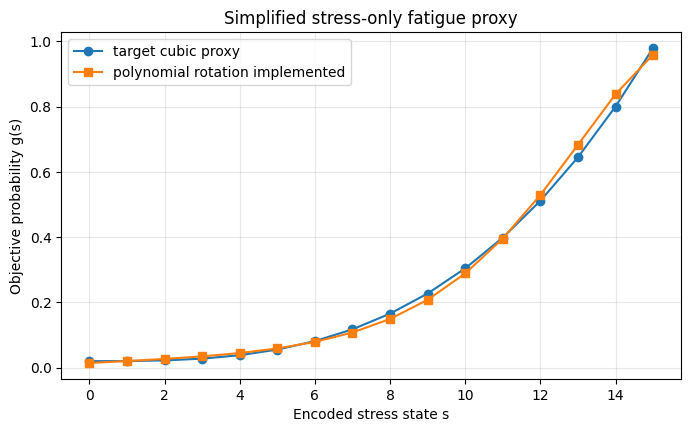

In [116]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(simple_model["states"], simple_model["target_probability"], marker="o", label="target cubic proxy")
ax.plot(simple_model["states"], simple_model["fitted_probability"], marker="s", label="polynomial rotation implemented")
ax.set_xlabel("Encoded stress state s")
ax.set_ylabel("Objective probability g(s)")
ax.set_title("Simplified stress-only fatigue proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### Simplified Model: Simulator

The simulator checks two things: direct sampling of the objective qubit from `A_simple`, and full iterative QAE on the same `EstimationProblem`. Both should estimate the implemented fitted mean, not the original bridge damage score.


In [117]:
simple_measured = simple_model["A"].copy(name="simple_poly_direct")
simple_creg = ClassicalRegister(1, "objective")
simple_measured.add_register(simple_creg)
simple_measured.measure(simple_model["input_qubits"], simple_creg[0])

simple_counts, simple_direct_p1 = objective_probability_from_sampler(
    simple_measured,
    shots=max(65536, KINGSTON_SHOTS),
)

simple_sim_iae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,
    alpha=0.05,
    sampler=StatevectorSampler(default_shots=8192, seed=RNG_SEED),
)
simple_sim_qae_result = simple_sim_iae.estimate(simple_model["problem"])
simple_sim_qae_mean = simple_sim_qae_result.estimation

simple_simulator_comparison = pd.DataFrame(
    [
        {
            "method": "target cubic proxy mean",
            "estimate": simple_model["target_mean"],
            "reference": "analytic average of g(s)",
        },
        {
            "method": "implemented polynomial mean",
            "estimate": simple_model["fitted_mean"],
            "reference": "exact mean of fitted rotation probabilities",
        },
        {
            "method": "simulator direct sampling",
            "estimate": simple_direct_p1,
            "reference": "StatevectorSampler measured A_simple",
        },
        {
            "method": "simulator full QAE",
            "estimate": simple_sim_qae_mean,
            "reference": "IAE on A_simple and Q_simple",
        },
    ]
)
simple_simulator_comparison["error_vs_fitted_mean"] = simple_simulator_comparison["estimate"] - simple_model["fitted_mean"]
simple_simulator_comparison


,method,estimate,reference,error_vs_fitted_mean
0,target cubic proxy mean,0.276000,analytic average of g(s),-0.001488
1,implemented polynomial mean,0.277488,exact mean of fitted rotation probabilities,0.000000
2,simulator direct sampling,0.276825,StatevectorSampler measured A_simple,-0.000663
3,simulator full QAE,0.277055,IAE on A_simple and Q_simple,-0.000433


### Simplified Model: Kingston Direct Sampling

This is the real-device version of the direct sampling check. It prepares `A_simple`, measures the objective qubit, and estimates $E[g(S)]$ from the measured probability. It has separate hardware flags so it will not run unless explicitly enabled.


In [118]:
if kingston_device is not None:
    simple_kingston_pass_manager = generate_preset_pass_manager(
        backend=kingston_device,
        optimization_level=1,
        seed_transpiler=RNG_SEED,
    )
    simple_kingston_isa_circuit = simple_kingston_pass_manager.run(simple_measured)
else:
    simple_kingston_pass_manager = None
    simple_kingston_isa_circuit = simple_measured

pd.DataFrame(
    {
        "metric": [
            "simple logical qubits",
            "encoded stress states",
            "depth before transpilation",
            "depth after transpilation/dry-run",
            "target mean",
            "implemented fitted mean",
        ],
        "value": [
            simple_measured.num_qubits,
            len(simple_model["states"]),
            simple_measured.depth(),
            simple_kingston_isa_circuit.depth(),
            simple_model["target_mean"],
            simple_model["fitted_mean"],
        ],
    }
)


,metric,value
0,simple logical qubits,5.000000
1,encoded stress states,16.000000
2,depth before transpilation,3.000000
3,depth after transpilation/dry-run,964.000000
4,target mean,0.276000
5,implemented fitted mean,0.277488


In [119]:
if RUN_KINGSTON_SIMPLE_HARDWARE and KINGSTON_SUBMIT_CONFIRMED:
    if kingston_device is None:
        raise RuntimeError("Set valid IBM Quantum credentials before submitting the simplified hardware circuit.")

    simple_kingston_sampler = RuntimeSamplerV2(
        mode=kingston_device,
        options={"default_shots": KINGSTON_SHOTS},
    )
    simple_kingston_job = simple_kingston_sampler.run([simple_kingston_isa_circuit], shots=KINGSTON_SHOTS)
    print(f"Submitted simplified {IBM_BACKEND_NAME} direct-sampling job: {simple_kingston_job.job_id()}")
elif RUN_KINGSTON_SIMPLE_HARDWARE:
    simple_kingston_job = None
    print("Simplified hardware submission blocked: set KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job.")
else:
    simple_kingston_job = None
    print("Simplified direct hardware run disabled. Set RUN_KINGSTON_SIMPLE_HARDWARE=true to submit.")


Simplified direct hardware run disabled. Set RUN_KINGSTON_SIMPLE_HARDWARE=true to submit.


In [120]:
if simple_kingston_job is not None:
    simple_kingston_result = simple_kingston_job.result()
    simple_kingston_counts = get_objective_counts(simple_kingston_result)
    simple_kingston_direct = damage_mean_from_objective_counts(simple_kingston_counts, scale=1.0)
    simple_kingston_direct_mean = simple_kingston_direct["hardware_damage_mean"]
    display(pd.DataFrame([simple_kingston_direct]))
else:
    simple_kingston_result = None
    simple_kingston_counts = None
    simple_kingston_direct = None
    simple_kingston_direct_mean = np.nan
    print("No simplified direct hardware result yet.")


No simplified direct hardware result yet.


### Simplified Model: Kingston Full QAE

This optional cell runs full iterative QAE on the simplified polynomial oracle. It should be substantially more reasonable than full QAE on the empirical bucket oracle because the simplified oracle is shallower and structured.


In [121]:
if RUN_KINGSTON_SIMPLE_QAE and KINGSTON_SUBMIT_CONFIRMED:
    if kingston_device is None:
        raise RuntimeError("Set valid IBM Quantum credentials before submitting simplified QAE.")

    simple_qae_pass_manager = generate_preset_pass_manager(
        backend=kingston_device,
        optimization_level=1,
        seed_transpiler=RNG_SEED,
    )
    raw_simple_qae_sampler = RuntimeSamplerV2(
        mode=kingston_device,
        options={"default_shots": KINGSTON_SHOTS},
    )
    simple_qae_sampler = RuntimeSamplerWithShotsMetadata(
        raw_simple_qae_sampler,
        shots=KINGSTON_SHOTS,
    )
    simple_hardware_iae = IterativeAmplitudeEstimation(
        epsilon_target=0.02,
        alpha=0.05,
        sampler=simple_qae_sampler,
        transpiler=simple_qae_pass_manager,
    )
    simple_kingston_qae_result = simple_hardware_iae.estimate(simple_model["problem"])
    simple_kingston_qae_mean = simple_kingston_qae_result.estimation
    print(f"Simplified Kingston QAE estimate: {simple_kingston_qae_mean:.6f}")
    print(f"Implemented fitted mean:          {simple_model['fitted_mean']:.6f}")
elif RUN_KINGSTON_SIMPLE_QAE:
    simple_kingston_qae_result = None
    simple_kingston_qae_mean = np.nan
    print("Simplified QAE submission blocked: set KINGSTON_SUBMIT_CONFIRM=submit-real-ibm-job.")
else:
    simple_kingston_qae_result = None
    simple_kingston_qae_mean = np.nan
    print("Simplified full hardware QAE disabled. Set RUN_KINGSTON_SIMPLE_QAE=true to submit.")


Simplified full hardware QAE disabled. Set RUN_KINGSTON_SIMPLE_QAE=true to submit.


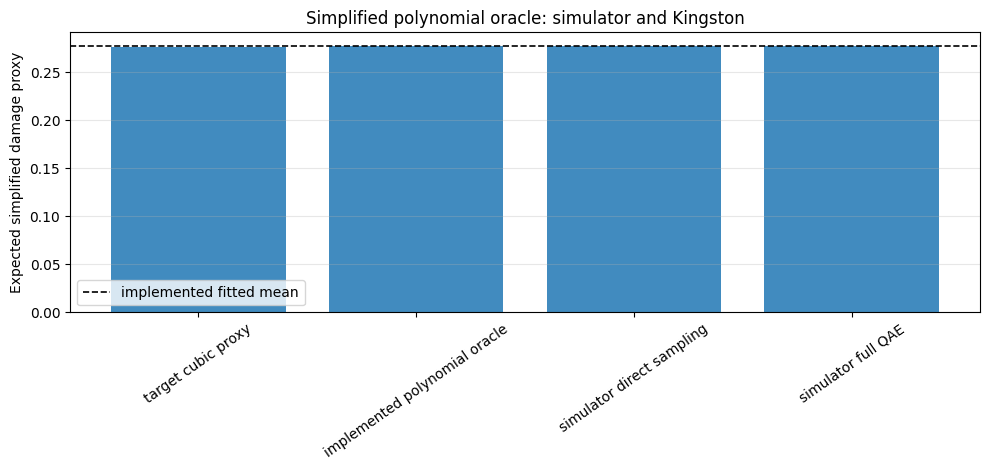

In [122]:
simple_final_comparison = pd.DataFrame(
    [
        {"method": "target cubic proxy", "estimate": simple_model["target_mean"]},
        {"method": "implemented polynomial oracle", "estimate": simple_model["fitted_mean"]},
        {"method": "simulator direct sampling", "estimate": simple_direct_p1},
        {"method": "simulator full QAE", "estimate": simple_sim_qae_mean},
        {"method": "Kingston direct sampling", "estimate": simple_kingston_direct_mean},
        {"method": "Kingston full QAE", "estimate": simple_kingston_qae_mean},
    ]
)
simple_final_comparison["error_vs_fitted_mean"] = simple_final_comparison["estimate"] - simple_model["fitted_mean"]

simple_final_comparison

plot_simple = simple_final_comparison.dropna(subset=["estimate"])
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(plot_simple["method"], plot_simple["estimate"], alpha=0.85)
ax.axhline(simple_model["fitted_mean"], color="black", linestyle="--", linewidth=1.2, label="implemented fitted mean")
ax.set_ylabel("Expected simplified damage proxy")
ax.set_title("Simplified polynomial oracle: simulator and Kingston")
ax.tick_params(axis="x", rotation=35)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Final Comparison and Hardware Diagnostic

The simulator and MC estimates agree because they implement the same encoded expectation. The Kingston estimates are higher. This is not a sign that the bridge damage expectation changed; it is a hardware diagnostic.

For the 16-bucket hardware circuit, the exact objective-qubit probability should be

$P(1) = E[D] / s$.

With the saved scale, that probability is around 0.37. A fully randomized objective bit would give $P(1) \approx 0.5$, which corresponds to a damage estimate of $0.5s$. The saved Kingston direct and full-QAE results are close to that random-bit baseline, so the likely cause is circuit noise pushing the measured objective qubit toward an unbiased 0/1 result.

This is consistent with the saved transpiled depth above 2000 for the 16-bucket amplitude-preparation circuit. Full QAE repeats amplified circuits, so it can inherit or amplify the same hardware-noise bias.


In [123]:
def maybe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


# Last saved hardware values from the current notebook run. They are used only when
# this comparison cell is run without live hardware result variables in memory.
LAST_SAVED_KINGSTON_DIRECT_MEAN = 4.779257514431204e-05
LAST_SAVED_KINGSTON_DIRECT_P1 = 0.4912109375
LAST_SAVED_KINGSTON_QAE_MEAN = 4.85413154e-05

comparison_scale = kingston_experiment["scale"]
exact_bucket_mean = kingston_experiment["exact_bucket_mean"]
expected_objective_p1 = exact_bucket_mean / comparison_scale
random_objective_mean = 0.5 * comparison_scale

# Local simulator check for the same measured direct circuit used by the hardware job.
LOCAL_SIM_SHOTS = max(65536, KINGSTON_SHOTS)
local_direct_counts, local_direct_p1 = objective_probability_from_sampler(
    kingston_measured_circuit,
    shots=LOCAL_SIM_SHOTS,
)
local_direct_mean = local_direct_p1 * comparison_scale

simulator_qae_row = qae_results.loc[qae_results["input_qubits"] == kingston_input_qubits]
if simulator_qae_row.empty:
    simulator_qae_mean = run_qae_for_buckets(
        make_equal_probability_buckets(df, input_qubits=kingston_input_qubits),
        epsilon_target=0.005,
    )["qae_mean"]
else:
    simulator_qae_mean = float(simulator_qae_row.iloc[0]["qae_mean"])

if isinstance(globals().get("kingston_hardware_estimate"), dict):
    kingston_direct_mean = maybe_float(kingston_hardware_estimate.get("hardware_damage_mean"))
    kingston_direct_p1 = maybe_float(kingston_hardware_estimate.get("p_objective_1"))
else:
    kingston_direct_mean = LAST_SAVED_KINGSTON_DIRECT_MEAN
    kingston_direct_p1 = LAST_SAVED_KINGSTON_DIRECT_P1

kingston_qae_mean_for_plot = maybe_float(globals().get("kingston_qae_mean"))
if np.isnan(kingston_qae_mean_for_plot):
    kingston_qae_mean_for_plot = LAST_SAVED_KINGSTON_QAE_MEAN

comparison = pd.DataFrame(
    [
        {
            "method": "Classical MC",
            "mean_damage": mc_mean,
            "p_objective_1": np.nan,
            "source": "full empirical CSV mean",
        },
        {
            "method": "Simulator direct sampling",
            "mean_damage": local_direct_mean,
            "p_objective_1": local_direct_p1,
            "source": "StatevectorSampler on measured A circuit",
        },
        {
            "method": "Simulator QAE",
            "mean_damage": simulator_qae_mean,
            "p_objective_1": simulator_qae_mean / comparison_scale,
            "source": "IterativeAmplitudeEstimation with StatevectorSampler",
        },
        {
            "method": "Kingston direct sampling",
            "mean_damage": kingston_direct_mean,
            "p_objective_1": kingston_direct_p1,
            "source": "saved/latest IBM Runtime direct sampling result",
        },
        {
            "method": "Kingston full QAE",
            "mean_damage": kingston_qae_mean_for_plot,
            "p_objective_1": kingston_qae_mean_for_plot / comparison_scale,
            "source": "saved/latest IBM Runtime IAE result",
        },
        {
            "method": "Random objective bit baseline",
            "mean_damage": random_objective_mean,
            "p_objective_1": 0.5,
            "source": "what the estimate becomes if hardware noise randomizes the objective qubit",
        },
    ]
)
comparison["relative_error_vs_mc"] = comparison["mean_damage"] / mc_mean - 1
comparison


,method,mean_damage,p_objective_1,source,relative_error_vs_mc
0,Classical MC,0.000036,NaN,full empirical CSV mean,0.000000
1,Simulator direct sampling,0.000036,0.368057,StatevectorSampler on measured A circuit,-0.006168
2,Simulator QAE,0.000036,0.370634,IterativeAmplitudeEstimation with StatevectorS...,0.000790
3,Kingston direct sampling,0.000047,0.481445,saved/latest IBM Runtime direct sampling result,0.300004
4,Kingston full QAE,0.000049,0.501693,saved/latest IBM Runtime IAE result,0.354676
5,Random objective bit baseline,0.000049,0.500000,what the estimate becomes if hardware noise ra...,0.350105


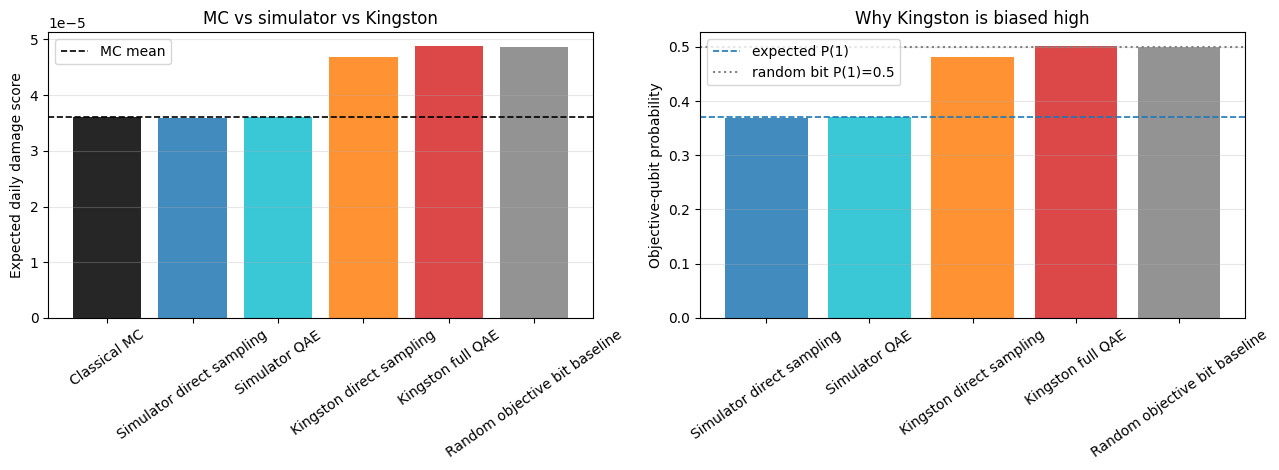

In [124]:
plot_data = comparison.copy()
colors = {
    "Classical MC": "black",
    "Simulator direct sampling": "tab:blue",
    "Simulator QAE": "tab:cyan",
    "Kingston direct sampling": "tab:orange",
    "Kingston full QAE": "tab:red",
    "Random objective bit baseline": "gray",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(
    plot_data["method"],
    plot_data["mean_damage"],
    color=[colors[m] for m in plot_data["method"]],
    alpha=0.85,
)
axes[0].axhline(mc_mean, color="black", linestyle="--", linewidth=1.2, label="MC mean")
axes[0].set_ylabel("Expected daily damage score")
axes[0].set_title("MC vs simulator vs Kingston")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

p_plot = plot_data.dropna(subset=["p_objective_1"])
axes[1].bar(
    p_plot["method"],
    p_plot["p_objective_1"],
    color=[colors[m] for m in p_plot["method"]],
    alpha=0.85,
)
axes[1].axhline(expected_objective_p1, color="tab:blue", linestyle="--", linewidth=1.2, label="expected P(1)")
axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1.5, label="random bit P(1)=0.5")
axes[1].set_ylabel("Objective-qubit probability")
axes[1].set_title("Why Kingston is biased high")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Reading the Final Plot

The left plot compares damage estimates. The right plot compares the underlying objective-qubit probabilities after scaling is removed.

The important observation is that the Kingston results are close to the random objective-bit baseline. Since the simulator direct circuit and simulator QAE agree with MC, the algorithmic encoding is internally consistent. The discrepancy is therefore most likely a hardware-depth/noise issue, not a mismatch between MC and QAE mathematics.

For a cleaner hardware demonstration, reduce `KINGSTON_INPUT_QUBITS` and `KINGSTON_QAE_INPUT_QUBITS` to 2 or 3, or add hardware-error mitigation/twirling/dynamical decoupling experiments. The 16-bucket circuit is useful educationally, but its transpiled depth is already high enough that the objective-qubit signal is strongly degraded.
